In [14]:
# --- Imports ---
import sys
sys.path.append("../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

from data_loader import DataLoader

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

## Stage 0 : Loading 

In [15]:
loader = DataLoader(data_dir="../../data")
print(f"Total aligned trials: {len(loader)}")

Found 2160 signal files in ../../data\MI CSV


[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Total aligned trials: 2160


## Stage 1 : Filters 

In [16]:
import os
import numpy as np
import pandas as pd

from scipy.signal import butter, sosfiltfilt


# --------------------------------------------------
# Stage 2 Filter configuration
# --------------------------------------------------

FS = 250

LOW_CUT = 0.5
HIGH_CUT = 40.0
FILTER_ORDER = 4

CHANNELS = ["FZ", "C3", "CZ", "C4"]

OUTPUT_DIR = "../../data/processed/filtered_trials"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [17]:
# Create a Butterworth band-pass filter
sos = butter(
    FILTER_ORDER,
    [LOW_CUT, HIGH_CUT],
    btype="bandpass",
    fs=FS,
    output="sos"
)

### filters is ready , now let's apply on all Trials

In [18]:
processed_records = []

for i in range(len(loader)):

    # Load original trial
    signal_df, label = loader.load_trial(i)

    trial_id = loader.valid_manifest.iloc[i]["trial_id"]

    # Work on a copy — never modify raw DataFrame/file
    processed_df = signal_df.copy()

    # --------------------------------------------------
    # Rebuild clean relative time axis
    # --------------------------------------------------

    processed_df["Time"] = np.arange(len(processed_df)) / FS

    # --------------------------------------------------
    # Apply band-pass filter to EEG channels
    # --------------------------------------------------

    for channel in CHANNELS:

        processed_df[channel] = sosfiltfilt(
            sos,
            processed_df[channel].values
        )

    # --------------------------------------------------
    # Save processed trial
    # --------------------------------------------------

    output_filename = f"cellula_MI_data_{trial_id}.csv"

    output_path = os.path.join(
        OUTPUT_DIR,
        output_filename
    )

    processed_df.to_csv(
        output_path,
        index=False
    )

    # Record processing information
    processed_records.append({
        "trial_id": trial_id,
        "file_path": output_path,
        "label": label
    })


processed_manifest = pd.DataFrame(processed_records)

print(f"Successfully filtered {len(processed_manifest)} trials.")

Successfully filtered 2160 trials.


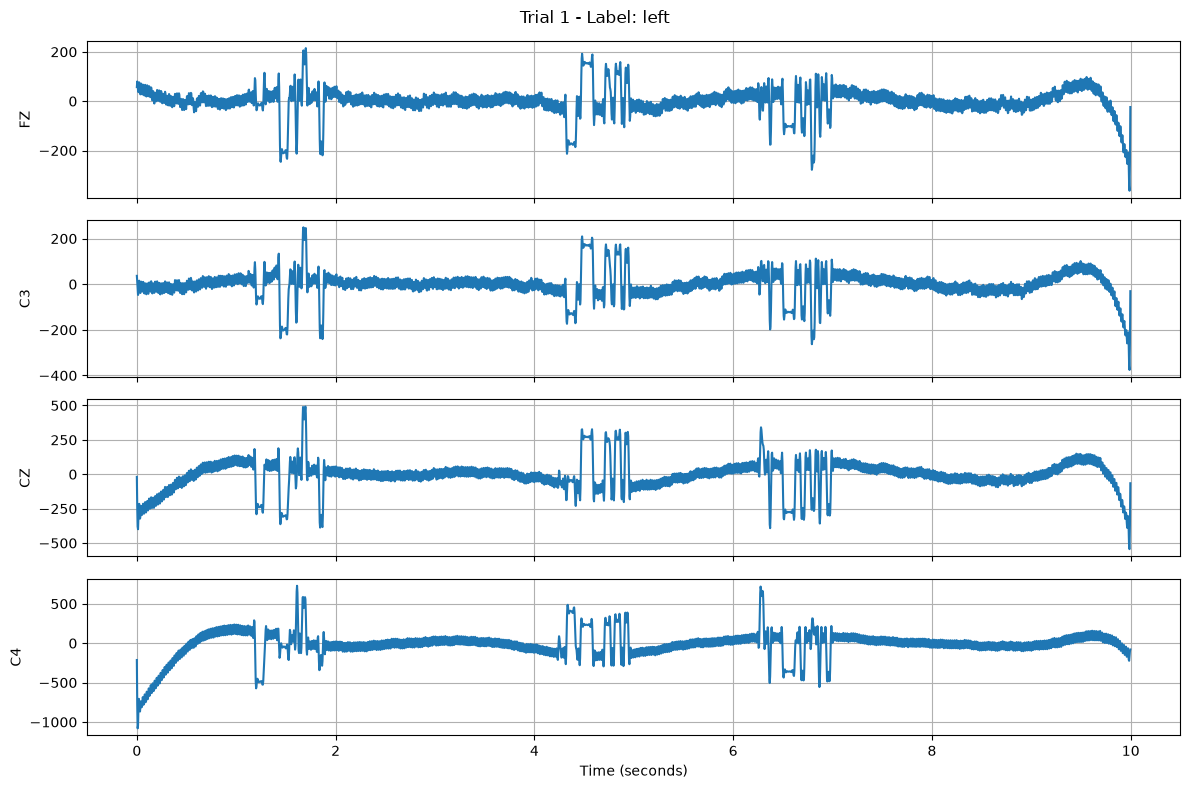

In [19]:
import matplotlib.pyplot as plt

# Load first trial
df = pd.read_csv(processed_manifest.iloc[0]["file_path"])

# Plot the first few EEG channels
channels_to_plot = CHANNELS[:4]  # Plot first 4 channels
fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(12, 8), sharex=True)

for idx, channel in enumerate(channels_to_plot):
    axes[idx].plot(df["Time"], df[channel])
    axes[idx].set_ylabel(channel)
    axes[idx].grid(True)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle(f"Trial {processed_manifest.iloc[0]['trial_id']} - Label: {processed_manifest.iloc[0]['label']}")
plt.tight_layout()
plt.show()

In [20]:
# Get the first trial's file path
first_row = processed_manifest.iloc[11]
file_path = first_row["file_path"]
trial_id = first_row["trial_id"]
label = first_row["label"]

# Load the CSV file
df = pd.read_csv(file_path)

# View basic info
print(f"Trial ID: {trial_id}")
print(f"Label: {label}")
print(f"Shape: {df.shape}")  # (rows, columns)
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nStatistical summary:")
print(df.describe())

Trial ID: 12
Label: right
Shape: (2500, 5)

Columns: ['Time', 'FZ', 'C3', 'CZ', 'C4']

First 5 rows:
    Time          FZ           C3           CZ           C4
0  0.000   23.287047   -39.204074  -214.006465 -1298.699701
1  0.004  332.717220   800.457852   792.082095    76.656495
2  0.008  527.144718  1314.140680  1418.485818   928.874634
3  0.012  550.212566  1355.288050  1482.246966  1010.512182
4  0.016  446.510918  1064.294358  1134.953953   535.626095

Statistical summary:
              Time           FZ           C3           CZ           C4
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean      4.998000     9.182295    27.136602    38.088687    75.130446
std       2.887329    79.777348   229.802650   286.447120  1161.460944
min       0.000000  -248.401807  -972.510042 -1147.480028 -7492.724982
25%       2.499000   -34.805536   -92.545150  -115.665911  -142.564678
50%       4.998000     8.912535    26.157128    23.630427    20.100998
75%       7.497000  

In [21]:
manifest_path = "../data/processed/processed_manifest.csv"

processed_manifest.to_csv(
    manifest_path,
    index=False
)

print(f"Manifest saved to: {manifest_path}")

Manifest saved to: ../data/processed/processed_manifest.csv


In [22]:
print(processed_manifest.head())
print()
print("Processed trials:", len(processed_manifest))

   trial_id                                          file_path  label
0         1  ../../data/processed/filtered_trials\cellula_M...   left
1         2  ../../data/processed/filtered_trials\cellula_M...  right
2         3  ../../data/processed/filtered_trials\cellula_M...   left
3         4  ../../data/processed/filtered_trials\cellula_M...   left
4         5  ../../data/processed/filtered_trials\cellula_M...   left

Processed trials: 2160


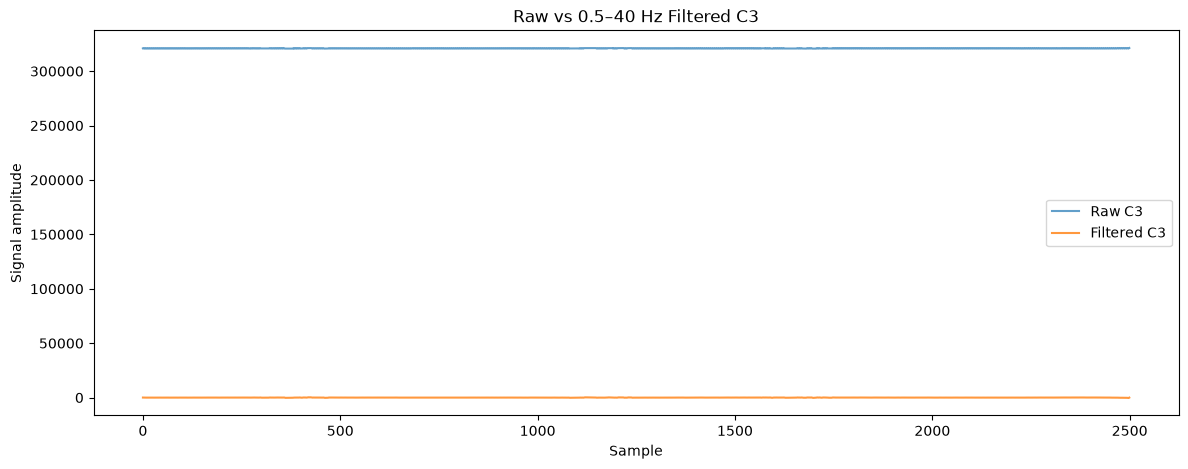

In [23]:
import matplotlib.pyplot as plt

raw_df, _ = loader.load_trial(0)

filtered_df = pd.read_csv(
    processed_manifest.iloc[0]["file_path"]
)

plt.figure(figsize=(14, 5))

plt.plot(
    raw_df["C3"],
    label="Raw C3",
    alpha=0.7
)

plt.plot(
    filtered_df["C3"],
    label="Filtered C3",
    alpha=0.8
)

plt.title("Raw vs 0.5–40 Hz Filtered C3")
plt.xlabel("Sample")
plt.ylabel("Signal amplitude")
plt.legend()
plt.show()

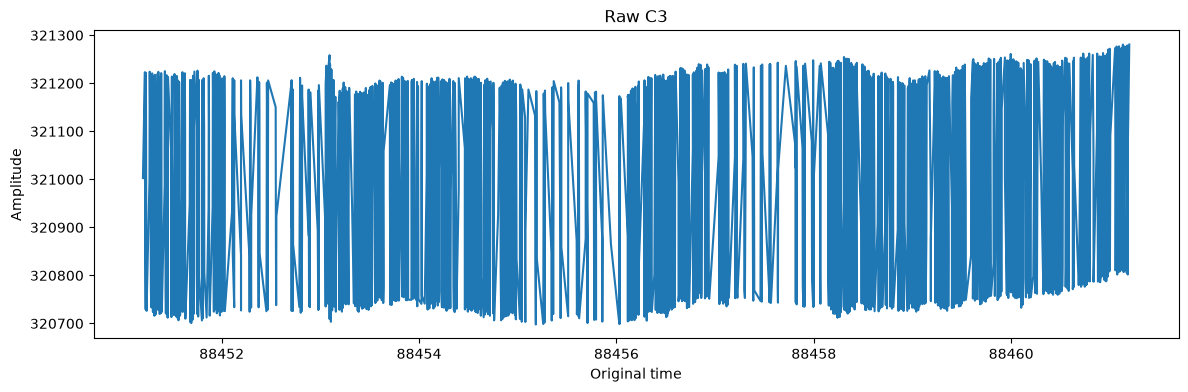

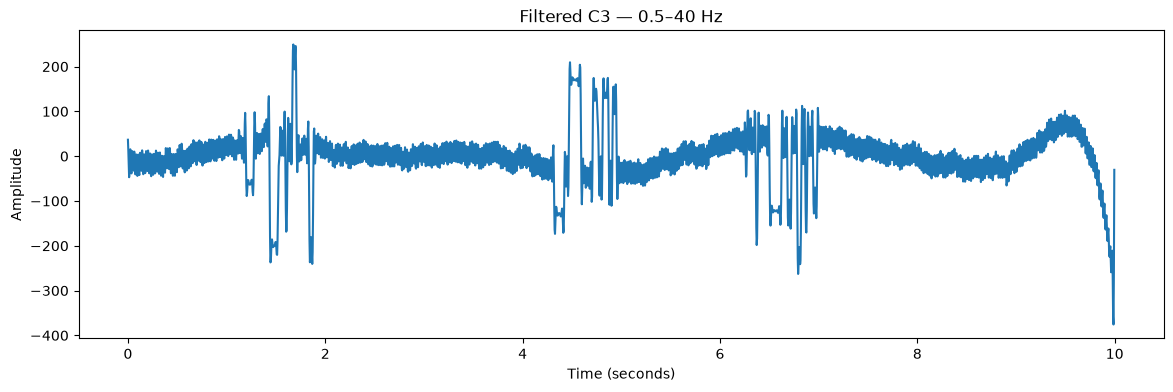

In [24]:
plt.figure(figsize=(14, 4))

plt.plot(raw_df["Time"], raw_df["C3"])

plt.title("Raw C3")
plt.xlabel("Original time")
plt.ylabel("Amplitude")
plt.show()


plt.figure(figsize=(14, 4))

plt.plot(filtered_df["Time"], filtered_df["C3"])

plt.title("Filtered C3 — 0.5–40 Hz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

## Stage 3 — Artifact rejection

### Using the rejection-candidates csv file we saved during EDA 

In [25]:
import pandas as pd

REJECTION_FILE = "../../data/rejection_candidates.csv"

rejection_df = pd.read_csv(REJECTION_FILE)

print(rejection_df.head())
print(f"Trials marked for rejection: {len(rejection_df)}")

rejected_ids = set(rejection_df["trial_id"])

print(f"Unique rejected trials: {len(rejected_ids)}")

   trial_id
0       460
1       461
2       462
3       463
4       464
Trials marked for rejection: 165
Unique rejected trials: 165


In [26]:
processed_manifest["rejected"] = (
    processed_manifest["trial_id"].isin(rejected_ids)
)

processed_manifest["rejected"].value_counts()

rejected
False    1995
True      165
Name: count, dtype: int64

In [27]:
rejected_summary = (
    processed_manifest[
        processed_manifest["rejected"]
    ]
    .groupby("label")
    .size()
)

print(rejected_summary)

class_counts = processed_manifest.groupby("label").size()

rejection_percentages = (
    rejected_summary / class_counts * 100
)

print("\nRejection percentage by class:")
print(rejection_percentages)

label
left     86
right    79
dtype: int64

Rejection percentage by class:
label
left     7.948244
right    7.328386
dtype: float64


In [28]:
clean_manifest = (
    processed_manifest[
        ~processed_manifest["rejected"]
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Trials before artifact rejection: {len(processed_manifest)}")
print(f"Rejected trials: {processed_manifest['rejected'].sum()}")
print(f"Remaining clean trials: {len(clean_manifest)}")

Trials before artifact rejection: 2160
Rejected trials: 165
Remaining clean trials: 1995


### Save the clean manifest

In [29]:
CLEAN_MANIFEST_PATH = "../data/processed/clean_manifest.csv"

clean_manifest.to_csv(
    CLEAN_MANIFEST_PATH,
    index=False
)

print(f"Clean manifest saved to: {CLEAN_MANIFEST_PATH}")

Clean manifest saved to: ../data/processed/clean_manifest.csv


In [30]:
remaining_bad_ids = set(
    clean_manifest["trial_id"]
) & rejected_ids

print("Rejected IDs still present:", len(remaining_bad_ids))

Rejected IDs still present: 0


In [31]:
# check class balance again after cleaning
clean_class_balance = clean_manifest["label"].value_counts()

print(clean_class_balance)

print("\nPercentages:")
print(
    clean_manifest["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
right    999
left     996
Name: count, dtype: int64

Percentages:
label
right    50.08
left     49.92
Name: proportion, dtype: float64


In [32]:
processing_report = {
    "original_trials": len(processed_manifest),
    "rejected_trials": int(processed_manifest["rejected"].sum()),
    "retained_trials": len(clean_manifest),
    "rejection_percentage": round(
        processed_manifest["rejected"].mean() * 100,
        2
    )
}

print(processing_report)

{'original_trials': 2160, 'rejected_trials': 165, 'retained_trials': 1995, 'rejection_percentage': np.float64(7.64)}


## Stage 4 — Re-referencing

In [33]:
import os
import pandas as pd

CHANNELS = ["FZ", "C3", "CZ", "C4"]

APPLY_CAR = True

INPUT_DIR = "../data/processed/filtered_trials"
OUTPUT_DIR = "../data/processed/rereferenced_trials"

os.makedirs(OUTPUT_DIR, exist_ok=True)

### The CAR function implentation

In [34]:
def apply_car(df, channels):
    """
    Apply Common Average Reference (CAR).

    For every time sample:
    1. Calculate the average across all EEG channels.
    2. Subtract that average from each channel.
    """

    df = df.copy()

    average_reference = df[channels].mean(axis=1)

    for channel in channels:
        df[channel] = df[channel] - average_reference

    return df

In [35]:
clean_manifest = pd.read_csv(
    "../data/processed/clean_manifest.csv"
)

reref_records = []

for _, row in clean_manifest.iterrows():

    trial_id = row["trial_id"]
    label = row["label"]

    input_path = row["file_path"]

    df = pd.read_csv(input_path)

    if APPLY_CAR:
        df = apply_car(df, CHANNELS)

    output_filename = f"cellula_MI_data_{trial_id}.csv"

    output_path = os.path.join(
        OUTPUT_DIR,
        output_filename
    )

    df.to_csv(
        output_path,
        index=False
    )

    reref_records.append({
        "trial_id": trial_id,
        "file_path": output_path,
        "label": label
    })


reref_manifest = pd.DataFrame(reref_records)

print(
    f"Successfully re-referenced "
    f"{len(reref_manifest)} retained trials."
)

Successfully re-referenced 1995 retained trials.


In [36]:
REREF_MANIFEST_PATH = (
    "../data/processed/rereferenced_manifest.csv"
)

reref_manifest.to_csv(
    REREF_MANIFEST_PATH,
    index=False
)

print(
    f"Re-referenced manifest saved to: "
    f"{REREF_MANIFEST_PATH}"
)

Re-referenced manifest saved to: ../data/processed/rereferenced_manifest.csv


In [37]:
sample_df = pd.read_csv(
    reref_manifest.iloc[0]["file_path"]
)

channel_average = sample_df[CHANNELS].mean(axis=1)

print(channel_average.describe())

count    2.500000e+03
mean     1.061928e-17
std      6.152453e-15
min     -4.263256e-14
25%     -1.776357e-15
50%      0.000000e+00
75%      1.776357e-15
max      3.552714e-14
dtype: float64


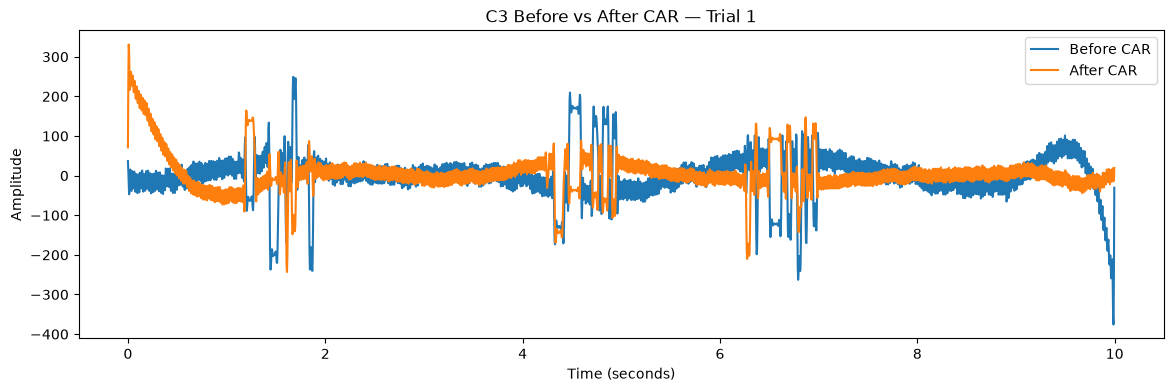

In [38]:
import matplotlib.pyplot as plt

trial_id = reref_manifest.iloc[0]["trial_id"]

before_path = clean_manifest[
    clean_manifest["trial_id"] == trial_id
].iloc[0]["file_path"]

after_path = reref_manifest.iloc[0]["file_path"]

before_df = pd.read_csv(before_path)
after_df = pd.read_csv(after_path)
plt.figure(figsize=(14, 4))

plt.plot(
    before_df["Time"],
    before_df["C3"],
    label="Before CAR"
)

plt.plot(
    after_df["Time"],
    after_df["C3"],
    label="After CAR"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(f"C3 Before vs After CAR — Trial {trial_id}")

plt.legend()
plt.show()

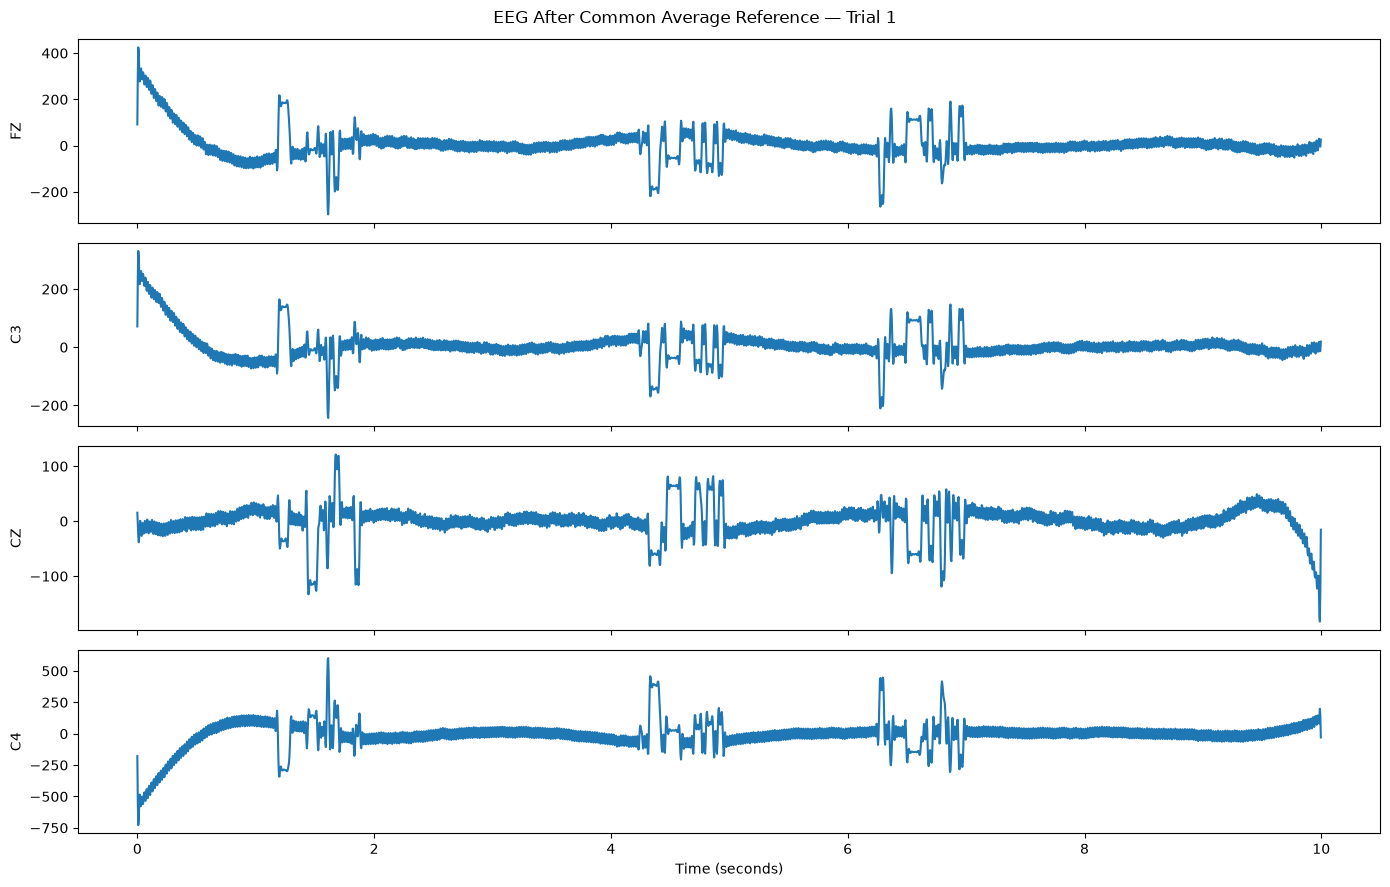

In [39]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 9),
    sharex=True
)

for ax, channel in zip(axes, CHANNELS):

    ax.plot(
        sample_df["Time"],
        sample_df[channel]
    )

    ax.set_ylabel(channel)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    f"EEG After Common Average Reference — "
    f"Trial {trial_id}"
)

plt.tight_layout()
plt.show()

## Epoching 

In [40]:
FS = 250

candidate_windows = [
    (0, 2),
    (1, 3),
    (2, 4),
    (3, 5),
    (4, 6),
    (5, 7),
    (6, 8),
    (7, 9),
    (8, 10),
]

In [41]:
def extract_epoch(df, start_sec, end_sec, fs=250):
    start_sample = int(start_sec * fs)
    end_sample = int(end_sec * fs)

    return df.iloc[start_sample:end_sample].copy()

In [42]:
import numpy as np
from scipy.signal import welch


def band_power(signal, fs, low, high):
    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(256, len(signal))
    )

    mask = (freqs >= low) & (freqs <= high)

    return np.trapezoid(
        psd[mask],
        freqs[mask]
    )

In [43]:
import pandas as pd

window_records = []

for start_sec, end_sec in candidate_windows:

    for _, row in clean_manifest.iterrows():

        df = pd.read_csv(row["file_path"])

        epoch = extract_epoch(
            df,
            start_sec,
            end_sec,
            fs=FS
        )

        record = {
            "trial_id": row["trial_id"],
            "label": row["label"],
            "window": f"{start_sec}-{end_sec}",
            "C3_mu": band_power(
                epoch["C3"].values,
                FS,
                8,
                12
            ),
            "C3_beta": band_power(
                epoch["C3"].values,
                FS,
                13,
                30
            ),
            "C4_mu": band_power(
                epoch["C4"].values,
                FS,
                8,
                12
            ),
            "C4_beta": band_power(
                epoch["C4"].values,
                FS,
                13,
                30
            ),
        }

        window_records.append(record)


window_features = pd.DataFrame(window_records)

### LEFT vs RIGHT differences per window

In [44]:
from scipy.stats import ttest_ind

results = []

for window in window_features["window"].unique():

    temp = window_features[
        window_features["window"] == window
    ]

    for feature in [
        "C3_mu",
        "C3_beta",
        "C4_mu",
        "C4_beta"
    ]:

        left = temp[
            temp["label"] == "left"
        ][feature]

        right = temp[
            temp["label"] == "right"
        ][feature]

        t_stat, p_value = ttest_ind(
            left,
            right,
            equal_var=False
        )

        results.append({
            "window": window,
            "feature": feature,
            "t_stat": t_stat,
            "p_value": p_value
        })


window_stats = pd.DataFrame(results)

display(window_stats)

,window,feature,t_stat,p_value
0,0-2,C3_mu,0.436275,0.662685
1,0-2,C3_beta,1.417082,0.156657
2,0-2,C4_mu,-1.307341,0.191264
3,0-2,C4_beta,-1.068027,0.285643
4,1-3,C3_mu,-0.384717,0.700489
5,1-3,C3_beta,0.009760,0.992213
6,1-3,C4_mu,-1.426355,0.153975
7,1-3,C4_beta,-0.839944,0.401042
8,2-4,C3_mu,0.464498,0.642347
9,2-4,C3_beta,0.433493,0.664716


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

features = [
    "C3_mu",
    "C3_beta",
    "C4_mu",
    "C4_beta"
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for window in window_features["window"].unique():

    temp = window_features[
        window_features["window"] == window
    ]

    X = temp[features]
    y = temp["label"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy"
    )

    cv_results.append({
        "window": window,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })


cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values(
        "mean_accuracy",
        ascending=False
    )
)

,window,mean_accuracy,std_accuracy
0,0-2,0.511113,0.012534
6,6-8,0.509570,0.008352
3,3-5,0.508465,0.004636
4,4-6,0.505570,0.008075
8,8-10,0.503513,0.008248
5,5-7,0.503085,0.011970
2,2-4,0.497980,0.004834
1,1-3,0.496985,0.009367
7,7-9,0.495000,0.008282


### Epoching Conclusion

- All tested 2-second windows gave about **50% cross-validation accuracy**, which is near random chance.
- No time window showed a clear advantage.
- Therefore, we will **not permanently crop the trials at this stage**.
- The full cleaned trials will be kept, and model-specific processing will be tested later:
  - **CSP + SVM:** focus on 8–30 Hz.
  - **EEGNet:** use cleaned time-series EEG.
- CAR will remain an optional branch for comparison.